# Transformaciones geométricas y cambio de perspectiva

En este cuaderno vas a rectificar una carta fotografiada en perspectiva para verla de frente. La idea central es entender que la transformación depende de elegir bien puntos de origen y puntos de destino.


## Objetivo

Construir una transformación de perspectiva a partir de cuatro esquinas y usarla para obtener una versión frontal de una carta dentro de una fotografía.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- identificar coordenadas de origen sobre una imagen;
- definir una geometría de destino ordenada;
- calcular una matriz de perspectiva con OpenCV;
- interpretar qué cambia y qué se preserva en una rectificación.

## Relación con la secuencia

Este cuaderno retoma la lectura de coordenadas trabajada en operaciones básicas y la lleva a una transformación más específica. Más adelante, la lógica de elegir puntos y transformar regiones vuelve a aparecer en tareas de anotación y segmentación.


## Módulos que vamos a usar

- `cv2`: para calcular la matriz de perspectiva y aplicar la transformación.
- `numpy`: para organizar las coordenadas en arreglos de puntos.
- `matplotlib.pyplot`: para comparar la imagen original, los puntos marcados y el resultado.
- `pathlib.Path`: para ubicar la imagen de trabajo.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = Path("/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/005/004 - computer_vision_parte_1/Imagenes/cards.jpg")
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


## 1. Imagen original

Primero miramos la escena completa. Después vamos a seleccionar una sola carta y marcar sus cuatro esquinas.


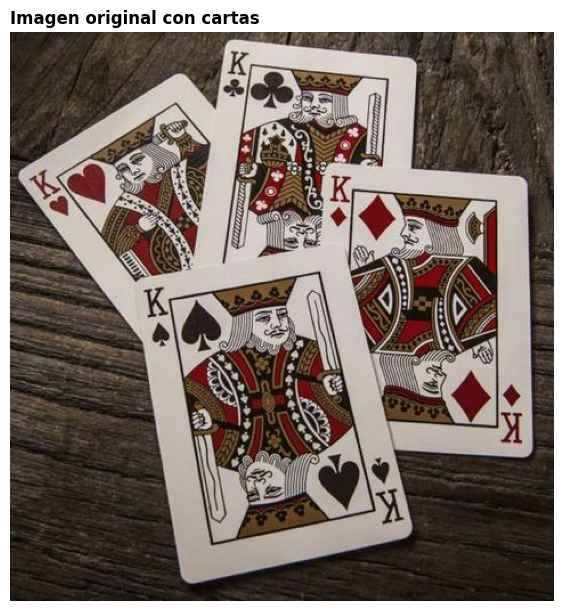

In [4]:
plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen original con cartas", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Elegir puntos de origen

Para corregir la perspectiva no alcanza con decir “quiero esa carta”. Necesitamos cuatro puntos bien ubicados. Esos puntos describen el cuadrilátero que vamos a transformar.


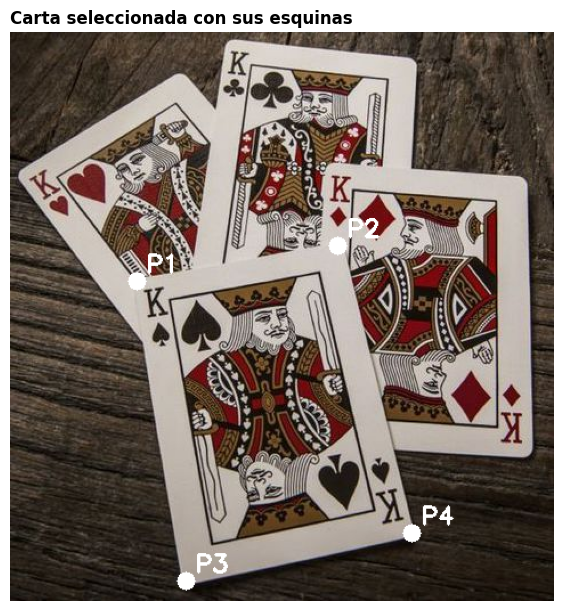

In [5]:
esquinas_origen = np.array(
    [
        [111, 219],
        [287, 188],  #Crea un arreglo de NumPy con las coordenadas de las cuatro esquinas de la carta
        [154, 482],
        [352, 440],
    ],
    dtype=np.float32, #OpenCV espera este tipo de dato para funciones geométricas
)

imagen_con_esquinas = imagen_rgb.copy() #Crea una copia de la imagen original para poder dibujar encima los puntos y etiquetas sin modificar la imagen original
for numero, punto in enumerate(esquinas_origen, start=1): #Recorre el arreglo esquinas_origen punto por punto recorriendo cada esquina para dibujarla y etiquetarla sobre la imagen
    x, y = int(punto[0]), int(punto[1]) #Toma el punto actual y separa sus dos coordenadas
    cv2.circle(imagen_con_esquinas, (x, y), 8, (255, 255, 255), -1) #define el centro del círculo blanco en la posición (x, y) de radio 8, color blanco y relleno completo para marcar visualmente su ubicación.
    cv2.putText(      #Se agrega una etiqueta a cada esquina para identificar el orden de los puntos, lo cual es importante para la transformación posterioro
        imagen_con_esquinas,
        f"P{numero}",
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
    )

plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_con_esquinas)
plt.title("Carta seleccionada con sus esquinas", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


Fijate que el orden de los puntos importa. Si cambiás el orden, la transformación puede deformar la carta en vez de rectificarla. Por eso conviene mantener una lógica estable, por ejemplo: arriba-izquierda, arriba-derecha, abajo-izquierda, abajo-derecha.


## 3. Definir los puntos de destino

Ahora vamos a decidir cómo queremos ver esa carta al final: como un rectángulo frontal con ancho y alto bien definidos.


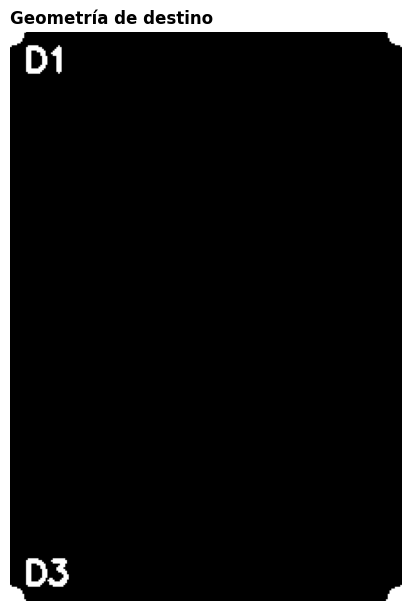

In [6]:
ancho_destino = 220 #Se definen las dimensiones del rectángulo final donde se proyectará la carta "enderezada"
alto_destino = 320

esquinas_destino = np.array( #Define las 4 esquinas del rectángulo final
    [
        [0, 0],
        [ancho_destino - 1, 0],
        [0, alto_destino - 1],
        [ancho_destino - 1, alto_destino - 1],
    ],
    dtype=np.float32, #Se definen las coordenadas de las esquinas del rectángulo de destino, que representan cómo se desea ver la carta corregida en perspectiva
)

lienzo_destino = np.zeros((alto_destino, ancho_destino, 3), dtype=np.uint8) #Se crea una imagen vacía para visualizar la posición de las esquinas en el espacio de destino
for numero, punto in enumerate(esquinas_destino, start=1):
    x, y = int(punto[0]), int(punto[1]) #Se etiquetan los puntos destino para verificar su correcta ubicación dentro del rectángulo final
    cv2.circle(lienzo_destino, (x, y), 8, (255, 255, 255), -1)
    cv2.putText(lienzo_destino, f"D{numero}", (x + 8, min(y + 22, alto_destino - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

plt.figure(figsize=(5, 6), constrained_layout=True) #Se visualiza la geometría de destino para comprobar la disposición de las esquinas del rectángulo final
plt.imshow(lienzo_destino)
plt.title("Geometría de destino", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


En esta celda se definen las coordenadas del rectángulo de destino, que representa la forma en la que se desea visualizar la carta una vez corregida. Se establece un ancho y alto específicos, y se ubican las cuatro esquinas correspondientes. Luego, se visualizan estos puntos sobre un lienzo vacío para verificar su correcta disposición.

## 4. Calcular la transformación y rectificar la carta

Con los puntos de origen y de destino ya definidos, OpenCV puede calcular una matriz que describe cómo pasar de una geometría a la otra.


Esta celda:

calcula la matriz de transformación de perspectiva

usa esa matriz para rectificar la carta

muestra:

la imagen original

los puntos elegidos

la carta ya corregida

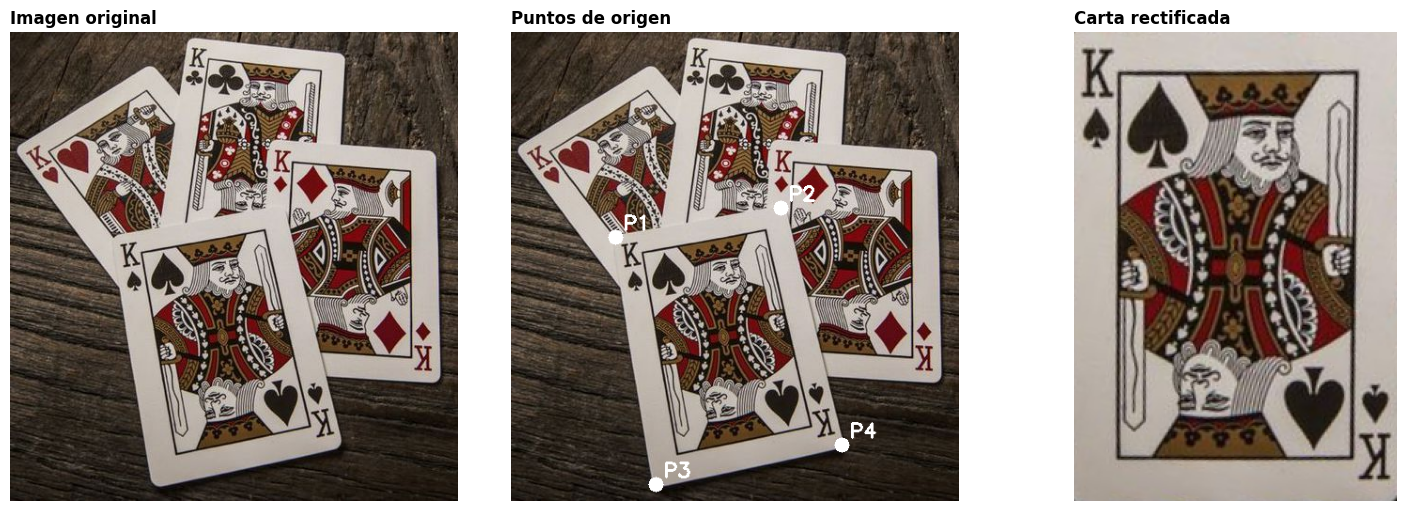

In [7]:
matriz_perspectiva = cv2.getPerspectiveTransform(esquinas_origen, esquinas_destino) #Calcula una matriz que indica cómo transformar los 4 puntos del origen en los 4 puntos del destino.
                                                                                    #Devuelve una matriz 3x3 que contiene la transformación proyectiva

imagen_rectificada = cv2.warpPerspective(imagen_rgb, matriz_perspectiva, (ancho_destino, alto_destino)) #Aplica la matriz calculada sobre la imagen original para generar una nueva imagen rectificada

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")

ejes[1].imshow(imagen_con_esquinas)
ejes[1].set_title("Puntos de origen", fontweight="bold", loc="left")
ejes[1].axis("off")

ejes[2].imshow(imagen_rectificada)
ejes[2].set_title("Carta rectificada", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


El resultado no crea información nueva, pero reorganiza la que ya estaba en la fotografía. La carta sigue siendo la misma, aunque ahora se ve más cercana a una vista frontal.


Se aplica la transformación de perspectiva sobre la imagen original para obtener una nueva imagen en la que la carta queda rectificada y alineada con la geometría de destino.

## Actividad breve

Elegí otra carta de la imagen y repetí el procedimiento. Después respondé:

1. ¿qué puntos marcaste como origen?
2. ¿mantuviste un orden consistente?
3. ¿la carta final quedó realmente rectificada o todavía conserva deformaciones?


## Cierre

La transformación de perspectiva muestra una idea importante: en visión por computadora no siempre alcanza con mirar una imagen, también hace falta reorganizar su geometría para poder analizarla mejor. Elegir bien los puntos es tan importante como aplicar la función correcta.
